# Praktikum Mandiri 13

---


Nama : Sintia Sari

NIM : 0110222135

Matkul : Machine Learning | Sesi Pagi

Rombel : TI08 - 2022

---


**Abstrak**

Pada praktikum ini dilakukan penerapan model Multilayer Perceptron (MLP) untuk mengenali angka tulisan tangan menggunakan dataset MNIST. Proses dimulai dari pemuatan dan normalisasi data, pembangunan arsitektur model, hingga pelatihan dan evaluasi model. Hasil pelatihan menunjukkan bahwa model mampu belajar dengan baik, ditandai dengan peningkatan akurasi dan penurunan nilai loss pada setiap epoch. Evaluasi menggunakan data uji menghasilkan tingkat akurasi sekitar 98%, yang menandakan bahwa model cukup akurat dalam melakukan klasifikasi angka. Visualisasi hasil prediksi dan grafik training juga memperlihatkan bahwa performa model stabil dan tidak mengalami overfitting secara signifikan. Dengan demikian, dapat disimpulkan bahwa model MLP yang dibangun berhasil mengenali angka tulisan tangan dengan performa yang baik.

# Import Library

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

Kode-kode diatas digunakan untuk menyiapkan library yang dibutuhkan dalam pembuatan dan evaluasi model deep learning. TensorFlow dipakai sebagai framework utama untuk membangun dan melatih model, sedangkan Keras (layers dan models) digunakan untuk menyusun struktur jaringan saraf. Matplotlib dan Seaborn berfungsi untuk menampilkan grafik dan visualisasi hasil, seperti akurasi atau confusion matrix. NumPy digunakan untuk mengolah data dalam bentuk array agar perhitungan lebih efisien, dan scikit-learn menyediakan fungsi evaluasi seperti confusion matrix dan classification report untuk melihat performa model klasifikasi secara lebih detail

# LOAD DATASET

In [2]:
print("Mengunduh dan memuat dataset MNIST...")
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

Mengunduh dan memuat dataset MNIST...
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Kode print("Mengunduh dan memuat dataset MNIST...") digunakan untuk menampilkan pesan di layar sebagai penanda bahwa program sedang mulai mengambil dataset MNIST. Baris (X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data() berfungsi untuk mengunduh sekaligus memuat dataset MNIST, lalu membaginya menjadi data latih (X_train dan y_train) dan data uji (X_test dan y_test), di mana X berisi gambar angka tulisan tangan dan y berisi label angkanya. Output yang muncul menunjukkan bahwa dataset berhasil diunduh dari internet, dengan ukuran sekitar 11 MB, dan proses pengunduhan selesai tanpa error, sehingga data siap digunakan untuk tahap selanjutnya seperti pelatihan dan pengujian model.

# Dimensi Dataset MNIST

In [4]:
X_train.shape, X_test.shape

((60000, 28, 28), (10000, 28, 28))

Kode X_train.shape, X_test.shape digunakan untuk melihat ukuran atau bentuk data gambar pada data latih dan data uji. Hasil (60000, 28, 28) berarti data latih terdiri dari 60.000 gambar, di mana setiap gambar berukuran 28 × 28 piksel, sedangkan (10000, 28, 28) menunjukkan data uji berjumlah 10.000 gambar dengan ukuran yang sama. Informasi ini penting untuk memastikan bahwa data sudah sesuai dan siap digunakan dalam proses pelatihan model.

# Normalisasi Data dan Penyiapan Label

In [3]:
train_images = X_train.astype('float32') / 255.0
test_images = X_test.astype('float32') / 255.0

train_labels = y_train
test_labels = y_test

Kode X_train.astype('float32') / 255.0 dan X_test.astype('float32') / 255.0 digunakan untuk mengubah tipe data gambar menjadi float lalu menormalkan nilainya ke rentang 0 sampai 1, karena nilai asli piksel berada di antara 0 hingga 255. Proses ini bertujuan agar perhitungan pada model menjadi lebih stabil dan hasil pelatihan lebih optimal. Sementara itu, train_labels = y_train dan test_labels = y_test berfungsi untuk menyiapkan label atau kelas dari setiap gambar, baik untuk data latih maupun data uji, sehingga model dapat belajar mengenali angka dengan benar sesuai label yang diberikan.

# Visualisasi Data Latih MNIST

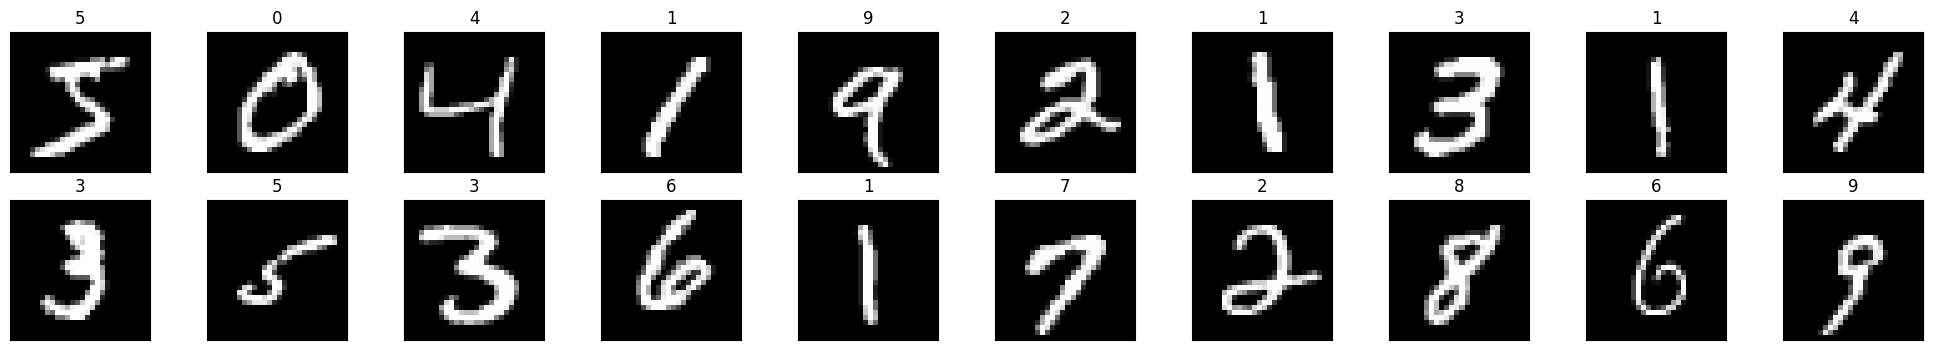

In [5]:
fig = plt.figure(figsize=(25, 4))
for idx in np.arange(20):
  ax = fig.add_subplot(2, int(20/2), idx+1, xticks=[], yticks=[])
  ax.imshow(np.squeeze(X_train[idx]), cmap='gray')
  ax.set_title(str(y_train[idx].item()))

Kode ini digunakan untuk menampilkan 20 gambar pertama dari dataset MNIST. Program membuat tampilan gambar dalam 2 baris dan 10 kolom, lalu menampilkan setiap gambar angka dalam bentuk hitam putih beserta label angkanya di atas gambar. Hasilnya, kita bisa melihat contoh data latih secara langsung untuk memastikan gambar dan label sudah sesuai sebelum digunakan untuk melatih model.

# Pembuatan Arsitektur Model MLP

In [7]:
# buat arsitektur yang kuat namun sederhana
mlp_model = models.Sequential([
    layers.Flatten(input_shape=(28, 28)),     # Mengubah matriks 2D ke 1D (784 unit)
    layers.Dense(256, activation='relu'),      # Hidden Layer 1: 256 neuron
    layers.Dropout(0.2),                       # Regulasi untuk mencegah overfitting
    layers.Dense(128, activation='relu'),      # Hidden Layer 2: 128 neuron
    layers.Dense(10, activation='softmax')     # Output Layer: 10 kelas (0-9)
])

Kode di atas digunakan untuk membangun arsitektur model Multilayer Perceptron (MLP) yang akan mengenali angka pada dataset MNIST. Model dibuat secara berurutan menggunakan Sequential. Lapisan Flatten berfungsi mengubah gambar 28×28 piksel menjadi satu baris data agar bisa diproses oleh jaringan saraf. Selanjutnya, Dense dengan 256 neuron dan aktivasi ReLU menjadi lapisan tersembunyi pertama untuk mempelajari pola data, lalu Dropout digunakan untuk mengurangi risiko model terlalu menghafal data latih (overfitting). Setelah itu, lapisan tersembunyi kedua dengan 128 neuron kembali memproses fitur yang telah dipelajari. Terakhir, lapisan output menggunakan 10 neuron dengan aktivasi softmax untuk menghasilkan prediksi angka dari 0 sampai 9.

# Proses Mompilasi Model

In [8]:
mlp_model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

Kode ini digunakan untuk menyiapkan model sebelum dilakukan pelatihan. Fungsi compile() mengatur cara model belajar dan dievaluasi. Optimizer adam dipakai untuk menyesuaikan bobot model agar kesalahan prediksi semakin kecil. Parameter loss='sparse_categorical_crossentropy' berfungsi menghitung tingkat kesalahan antara hasil prediksi model dan label asli yang berupa angka. Sementara itu, metrics=['accuracy'] digunakan untuk menampilkan tingkat akurasi agar kita bisa melihat seberapa baik model mengenali angka selama proses pelatihan.

# Proses Pelatihan Model MLP

In [9]:
print("\nMemulai proses pelatihan model...")
train_history = mlp_model.fit(train_images, train_labels,
                              epochs=10,
                              batch_size=32,
                              validation_split=0.2,
                              verbose=1)


Memulai proses pelatihan model...
Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8677 - loss: 0.4362 - val_accuracy: 0.9618 - val_loss: 0.1246
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9619 - loss: 0.1234 - val_accuracy: 0.9731 - val_loss: 0.0924
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.9730 - loss: 0.0887 - val_accuracy: 0.9697 - val_loss: 0.1025
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9774 - loss: 0.0711 - val_accuracy: 0.9765 - val_loss: 0.0775
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9821 - loss: 0.0558 - val_accuracy: 0.9772 - val_loss: 0.0813
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9835 - loss: 0.0500 - val_accuracy: 0.9753 - val_loss: 0.0870
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9860 - loss: 0.0418 - val_accuracy: 0.9759 - val_loss: 0.0871
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/st

Kode ini digunakan untuk melatih model yang sudah dibuat sebelumnya. Perintah print() hanya menampilkan pesan bahwa proses pelatihan akan dimulai. Fungsi mlp_model.fit() menjalankan proses training menggunakan data gambar (train_images) dan labelnya (train_labels) selama 10 kali pengulangan (epochs), dengan jumlah data yang diproses sekaligus sebanyak 32 (batch_size). Sebanyak 20% data latih digunakan sebagai data validasi (validation_split) untuk mengecek performa model saat training berlangsung. Hasil yang ditampilkan menunjukkan bahwa pada setiap epoch, akurasi model semakin meningkat dan nilai loss semakin menurun, baik pada data latih maupun data validasi. Hal ini menandakan bahwa model belajar dengan baik dan semakin mampu mengenali angka pada dataset MNIST.

# Proses Prediksi Data Uji

In [10]:
predictions = mlp_model.predict(X_test)
predictions

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


array([[0.        , 0.        , 0.        , ..., 0.99999994, 0.        ,
        0.        ],
       [0.        , 0.        , 0.99999994, ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.99999994, 0.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ]], dtype=float32)

Kode mlp_model.predict(X_test) digunakan untuk melakukan prediksi terhadap seluruh data uji menggunakan model yang sudah dilatih. Hasil prediksi tersebut disimpan ke dalam variabel predictions. Proses yang ditampilkan (313/313) menunjukkan jumlah batch yang diproses hingga seluruh data uji selesai diprediksi. Output berupa array angka desimal menandakan tingkat probabilitas untuk setiap kelas angka 0 sampai 9 pada tiap gambar. Nilai terbesar pada setiap baris menunjukkan angka yang paling diyakini oleh model sebagai hasil prediksi.

# Visualisasi Hasil Prediksi Model

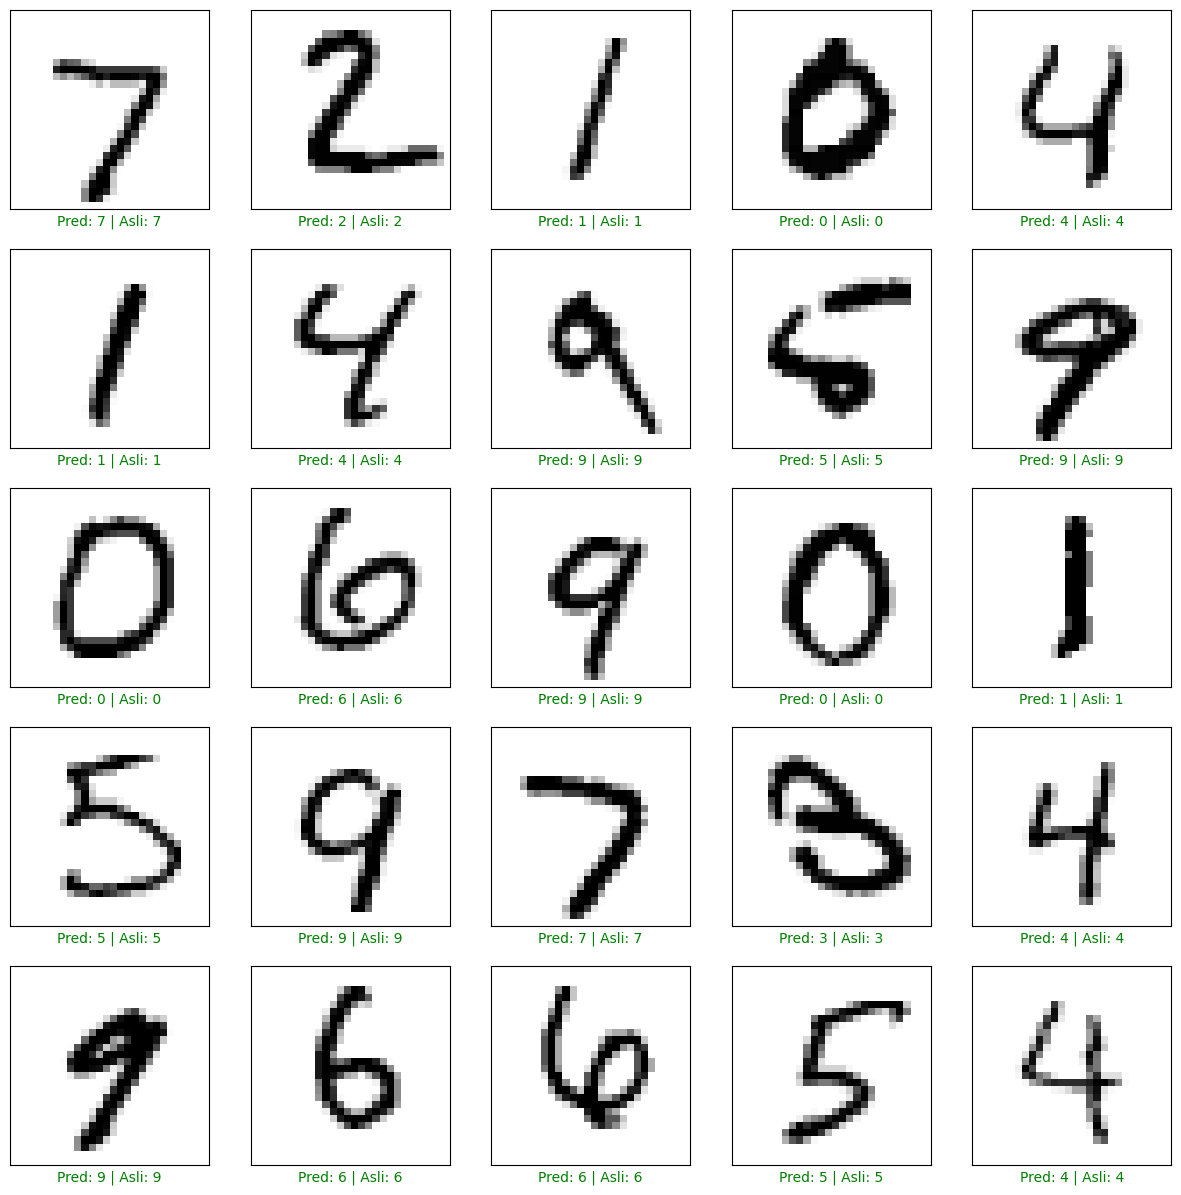

In [11]:
plt.figure(figsize=(15, 15))

for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)

    plt.imshow(X_test[i], cmap=plt.cm.binary)

    predicted_label = np.argmax(predictions[i])
    true_label = y_test[i]

    if predicted_label == true_label:
        color = 'green'
    else:
        color = 'red'
    plt.xlabel(f"Pred: {predicted_label} | Asli: {true_label}", color=color)

plt.show()

Kode ini digunakan untuk menampilkan hasil prediksi model pada 25 data uji pertama dalam bentuk gambar. Program membuat tampilan kotak gambar berukuran 5×5, lalu setiap gambar angka dari data uji ditampilkan tanpa sumbu agar terlihat lebih rapi. Pada setiap gambar, model mengambil nilai prediksi tertinggi sebagai hasil tebakan angka, kemudian dibandingkan dengan label aslinya. Jika hasil prediksi sesuai dengan angka sebenarnya, teks keterangan akan berwarna hijau, sedangkan jika salah akan berwarna merah. Hasil pada gambar menunjukkan bahwa sebagian besar prediksi model sudah sesuai dengan angka aslinya, menandakan model mampu mengenali tulisan tangan dengan cukup baik.

# Evaluasi Performa Model pada Data Uji

In [12]:
loss, accuracy = mlp_model.evaluate(test_images, test_labels)

print("Test Loss     :", loss)
print("Test Accuracy :", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9756 - loss: 0.0997
Test Loss     : 0.07974991202354431
Test Accuracy : 0.980400025844574


Kode ini digunakan untuk menguji seberapa baik performa model pada data yang belum pernah dilihat sebelumnya, yaitu data uji. Fungsi mlp_model.evaluate() menghitung nilai loss dan accuracy berdasarkan test_images dan test_labels. Nilai loss menunjukkan seberapa besar kesalahan prediksi model, sedangkan accuracy menunjukkan tingkat ketepatan prediksi. Hasil yang ditampilkan memperlihatkan bahwa model memiliki akurasi sekitar 98%, yang berarti sebagian besar angka pada data uji berhasil dikenali dengan benar, sehingga dapat disimpulkan bahwa model bekerja dengan sangat baik.

# Visualisasi Perkembangan Akurasi dan Loss Selama Training

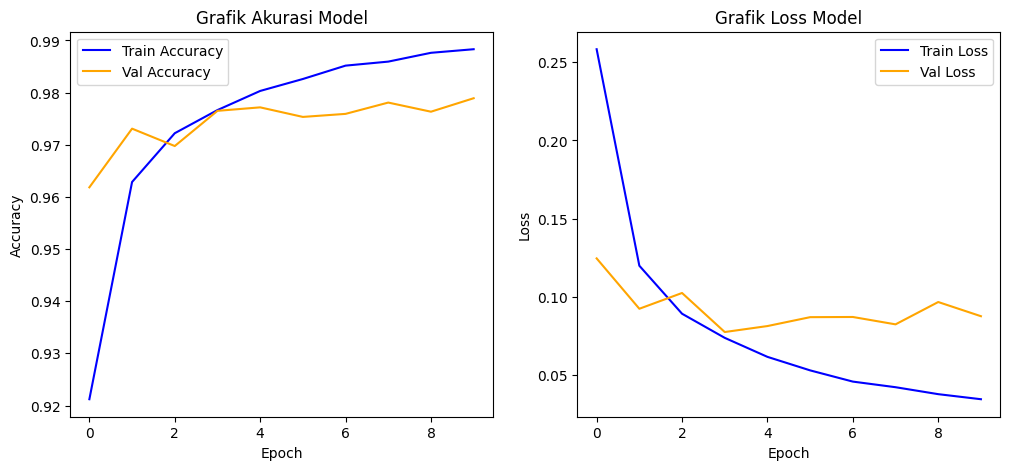

In [13]:
plt.figure(figsize=(12, 5))

# Plot Akurasi
plt.subplot(1, 2, 1)
plt.plot(train_history.history['accuracy'], label='Train Accuracy', color='blue')
plt.plot(train_history.history['val_accuracy'], label='Val Accuracy', color='orange')
plt.title('Grafik Akurasi Model')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(train_history.history['loss'], label='Train Loss', color='blue')
plt.plot(train_history.history['val_loss'], label='Val Loss', color='orange')
plt.title('Grafik Loss Model')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

Kode ini digunakan untuk menampilkan grafik hasil pelatihan model agar mudah dipahami. Program membuat dua grafik dalam satu tampilan: grafik akurasi dan grafik loss. Grafik akurasi menunjukkan perbandingan antara akurasi data latih dan data validasi pada setiap epoch, yang terlihat sama-sama meningkat, menandakan kemampuan model semakin baik. Grafik loss memperlihatkan penurunan nilai kesalahan pada data latih dan data validasi, yang berarti model semakin tepat dalam melakukan prediksi. Dari hasil grafik tersebut dapat disimpulkan bahwa proses training berjalan dengan baik dan model tidak mengalami masalah besar seperti overfitting.